In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load dataset
df = pd.read_csv("../../datasets/recruitment.csv")

# print shape of dataframe
print("Shape of dataframe:", df.shape)

# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# Check data types
df['Selected'] = df['Selected'].map({'Yes': 1, 'No': 0})

# print first 5 rows of dataframe
print("First 5 rows of dataframe:")
print(df.head())

Shape of dataframe: (27000, 11)

Missing values in each column:
Candidate_ID            0
Gender                  0
Race                    0
Age                     0
Education               0
Experience_Years        0
Job_Role_Applied        0
Skills                  0
Certifications      12765
Screening_Score         0
Selected                0
dtype: int64
First 5 rows of dataframe:
                           Candidate_ID  Gender      Race  Age Education  \
0  mostlyfa-2bdb-493a-a0f3-ed9ab51f7aa9  Female     White   28  Bachelor   
1  mostly49-894b-433c-9d43-0030178044f6    Male  Hispanic   48    Master   
2  mostlye8-47a9-4acb-ac11-63f4219927cf  Female     White   31    Master   
3  mostlyed-12b8-4915-825e-951390b65f19    Male  Hispanic   36  Bachelor   
4  mostlye1-ac47-48d0-81ce-9ff776545637  Female  Hispanic   29       PhD   

   Experience_Years   Job_Role_Applied  \
0                20  Software Engineer   
1                 0     Data Scientist   
2                16  Softwa

In [3]:
# LEVEL A: Population Representation
# measures whether each group appears proportionlly in the entire dataset.
# group proportion(Pi): Pi = ni / N; 
# where ni, is the number of candidates in group i, N is total number of candidate

# Balance Ratio(BR) = min(Pi) / max(Pi);
# ideal BR = 1.0
# BR < 0.8 indicates imbalanced dataset.

#Representation Gap (delta(i)): Compare dataset proportions with external labor market benchmarks (e.g., industry workforce demographics).
# delta(i) = |Pi - Bi|
# where Bi is the benchmark population proportion 




Gender Representation (%): Gender
Male          45.0
Female        38.0
Non-binary    16.0
Name: proportion, dtype: float64


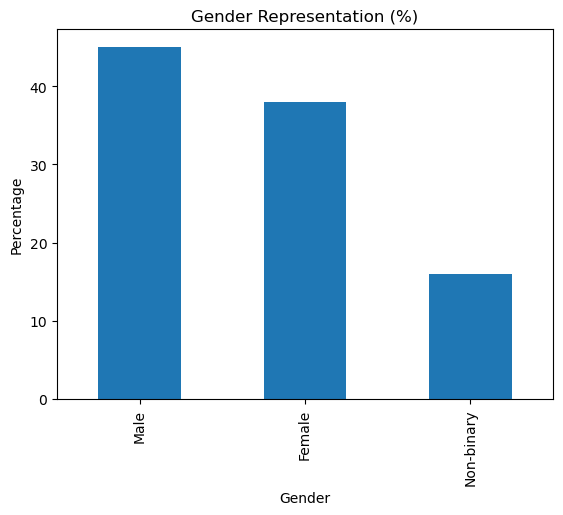


Balance Ratio (BR): $0.36

Representation Gap (%):
Female        12.0
Male           5.0
Non-binary     NaN
dtype: float64

Race Representation (%): Race
White       31.0
Black       25.0
Asian       19.0
Hispanic    16.0
Other        9.0
Name: proportion, dtype: float64


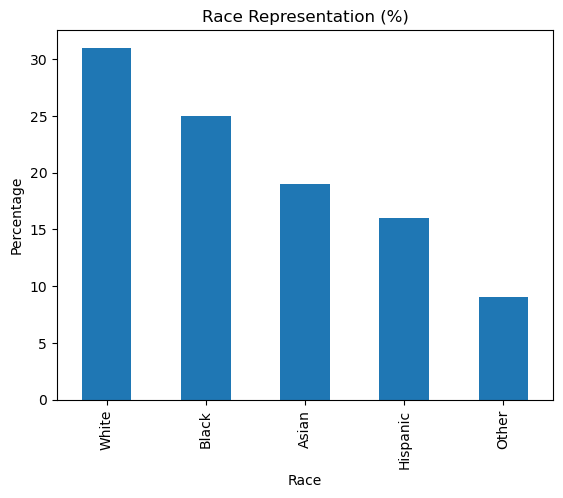


Balance Ratio (BR): $0.29

Representation Gap (%):
Asian        4.0
Black        5.0
Hispanic    11.0
Other        NaN
White       29.0
dtype: float64

Age Group Representation (%): Age_Group
26-35    45.0
18-25    27.0
36-45    20.0
46-55     6.0
56-65     2.0
Name: proportion, dtype: float64


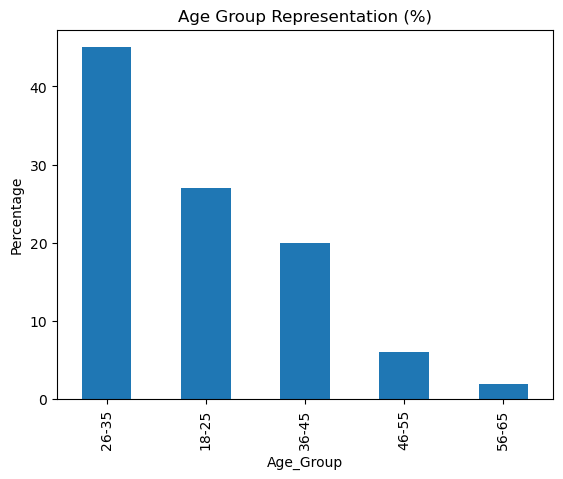


Balance Ratio (BR): $0.04

Representation Gap (%):
18-25    3.0
26-35    5.0
36-45    0.0
46-55    1.0
56-65    1.0
dtype: float64


In [4]:
# headings : Candidate_ID	Gender	Race	Age	Education	Experience_Years	Job_Role_Applied	Skills	Certifications	Screening_Score	Selected

# Gender Representation
gender_rep = df['Gender'].value_counts(normalize=True).round(2) * 100
print(f"\nGender Representation (%): {gender_rep}")

# plot a bar chart for gender representation
gender_rep.plot(kind='bar', title='Gender Representation (%)')
plt.ylabel('Percentage')
plt.show()

# Balance Ratio
balance_ratio = round(gender_rep.min() / gender_rep.max(), 2)
print(f"\nBalance Ratio (BR): ${balance_ratio}")

# Representation Gap
benchmark_gender = pd.Series({'Male': 50, 'Female': 50})
representation_gap = (gender_rep - benchmark_gender).abs()
print("\nRepresentation Gap (%):")
print(representation_gap)

# Race Representation
race_rep = df['Race'].value_counts(normalize=True).round(2) * 100
print(f"\nRace Representation (%): {race_rep}")

# plot a bar chart for race representation
race_rep.plot(kind='bar', title='Race Representation (%)')
plt.ylabel('Percentage')
plt.show()

# Balance Ratio
balance_ratio = round(race_rep.min() / race_rep.max(), 2)
print(f"\nBalance Ratio (BR): ${balance_ratio}")

# Representation Gap
# Assuming benchmark proportions (e.g., from industry reports)
benchmark_race = pd.Series({'White': 60, 'Black': 20, 'Asian': 15, 'Hispanic': 5})
representation_gap = (race_rep - benchmark_race).abs()
print("\nRepresentation Gap (%):")
print(representation_gap)


# Age Representation 
# Age groups: ['18-25', '26-35', '36-45', '46-55', '56-65']
df['Age_Group'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 55, 65], labels=['18-25', '26-35', '36-45', '46-55', '56-65'])
age_rep = df['Age_Group'].value_counts(normalize=True).round(2) * 100
print(f"\nAge Group Representation (%): {age_rep}")

# plot a bar chart for age group representation
age_rep.plot(kind='bar', title='Age Group Representation (%)')
plt.ylabel('Percentage')
plt.show()

# Balance Ratio
balance_ratio = round(age_rep.min() / age_rep.max(), 2)
print(f"\nBalance Ratio (BR): ${balance_ratio}")


# Representation Gap
# Assuming benchmark proportions (e.g., from industry reports)
benchmark_age = pd.Series({'18-25': 30, '26-35': 40, '36-45': 20, '46-55': 7, '56-65': 3})
representation_gap = (age_rep - benchmark_age).abs()
print("\nRepresentation Gap (%):")
print(representation_gap)

In [5]:
# LEVEL B: Selection Representation
# Measures whether the selection outcomes are proportional across groups.
# Selection Rate (SRi): selected_i / total_i; 

# Disparate Impact Ratio(DI) = SR (minority) / SR (majority);
# 0.8 ≤ DI ≤ 1.25 → fair range (EEOC Four-Fifths Rule)
# DI < 0.8 → potential adverse impact

# Outcome Representation Index (ORI): 
# ORI tells you whether a demographic group (like women or a racial minority) is proportionally represented among those who were selected/hired, relative to their representation in the total applicant pool.
# ORI(i) = (selected_i / total_selected) / (ni / N)
# where selected_i is number of selected candidates in group i
# total_selected is total number of selected candidates
# ni is number of candidates in group i
# N is total number of candidates

# ORI ≈ 1 → fair

# ORI < 0.8 or > 1.2 → potential under/over-selection bias


Gender Selection Rate (SRi): Gender
Female        0.17
Male          0.19
Non-binary    0.21
Name: Selected, dtype: float64


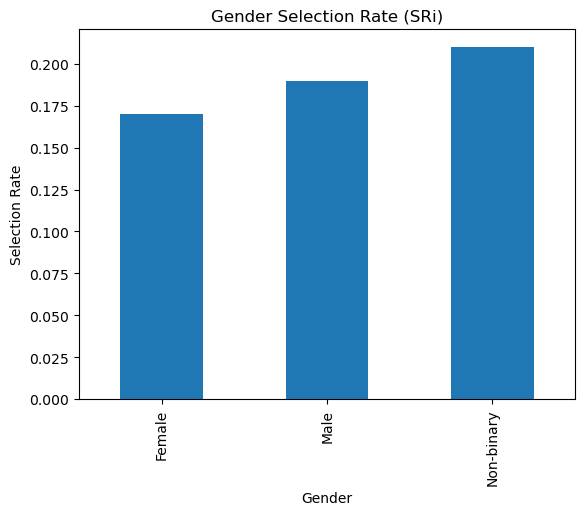


Disparate Impact Ratio (Gender) (DI): 0.81

Gender Outcome Representation Index (ORI):
       Gender  Total_in_Group  Selected   ORI
0  Non-binary            4441       952  1.14
1        Male           12185      2341  1.02
2      Female           10374      1769  0.91

Race Selection Rate (SRi): Race
Asian       0.16
Black       0.17
Hispanic    0.18
Other       0.21
White       0.21
Name: Selected, dtype: float64

Disparate Impact Ratio (Race) (DI): 0.76

Race Outcome Representation Index (ORI):
       Race  Total_in_Group  Selected   ORI
0     White            8269      1768  1.14
1     Other            2298       484  1.12
2  Hispanic            4348       800  0.98
3     Black            6845      1163  0.91
4     Asian            5240       847  0.86

Age Group Selection Rate (SRi): Age_Group
18-25    0.16
26-35    0.19
36-45    0.21
46-55    0.18
56-65    0.20
Name: Selected, dtype: float64


/var/folders/7_/qf5sf1f103bbvbxdw6lxcqn40000gn/T/ipykernel_79392/1426222195.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  selected_age_rate = df.groupby('Age_Group')['Selected'].mean().round(2)


In [6]:
# method to caluculate ORI
def calculate_ori(demographic_col, target_col='Selected'):
    total_selected = df[target_col].sum()
    total_candidates = len(df)

    ori_data = []
    for group, group_df in df.groupby(demographic_col):
        selected_i = group_df[target_col].sum()
        total_i = len(group_df)
        ori = ((selected_i / total_selected) / (total_i / total_candidates)) if total_selected > 0 else 0
        ori_data.append([group, total_i, selected_i, round(ori, 2)]) 
    
    ori_df = pd.DataFrame(ori_data, columns=[demographic_col, 'Total_in_Group', 'Selected', 'ORI'])
    return ori_df.sort_values(by='ORI', ascending=False).reset_index(drop=True)


# Gender Selection Representation
selected_gender_rate = df.groupby('Gender')['Selected'].mean().round(2)
print(f"\nGender Selection Rate (SRi): {selected_gender_rate}")

# plot a bar chart for gender selection rate
selected_gender_rate.plot(kind='bar', title='Gender Selection Rate (SRi)')
plt.ylabel('Selection Rate')
plt.show()

# Gender Disparate Impact Ratio
sr_minority = selected_gender_rate.min()
sr_majority = selected_gender_rate.max()
disparate_impact_ratio = round(sr_minority / sr_majority, 2)
print(f"\nDisparate Impact Ratio (Gender) (DI): {disparate_impact_ratio}")

# Gender Outcome Representation Index (ORI)
ori_gender = calculate_ori('Gender')
print("\nGender Outcome Representation Index (ORI):")
print(ori_gender)


# Race Selection Representation
selected_race_rate = df.groupby('Race')['Selected'].mean().round(2)
print(f"\nRace Selection Rate (SRi): {selected_race_rate}")

# Race Disparate Impact Ratio
sr_minority = selected_race_rate.min()
sr_majority = selected_race_rate.max()
disparate_impact_ratio = round(sr_minority / sr_majority, 2)
print(f"\nDisparate Impact Ratio (Race) (DI): {disparate_impact_ratio}")

# Race Outcome Representation Index (ORI)
ori_race = calculate_ori('Race')
print("\nRace Outcome Representation Index (ORI):")
print(ori_race)

# Age Group Selection Representation
selected_age_rate = df.groupby('Age_Group')['Selected'].mean().round(2)
print(f"\nAge Group Selection Rate (SRi): {selected_age_rate}")

In [7]:
# LEVEL C: Cross-Attribute Representation
# Bias can appear across intersecting demographic attributes (e.g., Gender and Race)

# P(i,j): Proportion of candidates in intersectional group (i,j)
# where i is demographic attribute 1 (e.g., Gender) and j is demographic attribute 2 (e.g., Race)

# P(i,j) = n(i,j) / N
# where n(i,j) is number of candidates in intersectional group (i,j)
# N is total number of candidates

In [8]:
# Method to calculate intersectional metric
def calculate_intersectional_metric(attrs, target_col='Selected', min_group_size=10):
    N = len(df)
    total_selected = df[target_col].sum()

    # group by intersectional attributes
    group = df.groupby(list(attrs), dropna=False)

    # raw counts
    cnt = group.size().rename('Total_in_Group')
    sel = group[target_col].sum().rename('Selected_in_Group')

    out = pd.concat([cnt, sel], axis=1).reset_index()

    # proportions and rates
    out['Overall_Proportion'] = (out['Total_in_Group'] / N).round(2)
    out['Selected_Proportion'] = (out['Selected_in_Group'] / max(total_selected,1)).round(2)  # avoid division by zero
    out['Selected_Rate'] = (out['Selected_in_Group'] / out['Total_in_Group']).round(2)  # avoid division by zero

    # Outcome Representation Index (ORI)
    out['ORI'] = (out['Selected_Proportion'] / out['Overall_Proportion']).replace([pd.NA, float('inf')], 0)

    # Disparate Impact Ratio (DIR)
    sr_ref = out.loc[out['Total_in_Group'] >= min_group_size, 'Selected_Rate']
    best_sr = sr_ref.max() if len(sr_ref) else out['Selected_Rate'].max()
    out['DI_vs_Best'] = out['Selected_Rate'] / (best_sr if best_sr > 0 else 1)

    # Flags (tweak thresholds as needed)
    def flag_ori(x):
        if x < 0.8: return 'Under-represented'
        if x > 1.2: return 'Over-represented'
        return 'Fair'
    out['Bias_Flag'] = out['ORI'].apply(flag_ori)

    # Pretty combo label
    out['Combo'] = out[list(attrs)].astype(str).agg(' × '.join, axis=1)

    # Stable sort: worst ORI first, then by DI
    out = out.sort_values(['ORI','DI_vs_Best']).reset_index(drop=True)

    # Reorder columns
    cols = list(attrs) + [
        'Combo','Total_in_Group','Selected_in_Group',
        'Overall_Proportion','Selected_Proportion','Selected_Rate',
        'ORI','DI_vs_Best','Bias_Flag'
    ]
    return out[cols]


# Gender x Race Intersection
intersectional_metric = calculate_intersectional_metric(['Gender', 'Race'])
print("\nGender x Race Intersectional Metric:")
print(intersectional_metric)


# Gender x Age_Group Intersection
intersectional_metric = calculate_intersectional_metric(['Gender', 'Age_Group'])
print("\nGender x Age_Group Intersectional Metric:")
print(intersectional_metric)


# Age_Group x Race Intersection
intersectional_metric = calculate_intersectional_metric(['Age_Group', 'Race'])
print("\nAge_Group x Race Intersectional Metric:")
print(intersectional_metric)


# Gender x Age_Group x Race Intersection
intersectional_metric = calculate_intersectional_metric(['Gender', 'Age_Group', 'Race'])
print("\nGender x Age_Group x Race Intersectional Metric:")
print(intersectional_metric)


Gender x Race Intersectional Metric:
        Gender      Race                  Combo  Total_in_Group  \
0       Female     Black         Female × Black            2887   
1       Female  Hispanic      Female × Hispanic            1527   
2       Female     Asian         Female × Asian            2022   
3         Male     Asian           Male × Asian            2345   
4         Male     Black           Male × Black            2921   
5         Male  Hispanic        Male × Hispanic            2110   
6   Non-binary     Asian     Non-binary × Asian             873   
7   Non-binary     Other     Non-binary × Other             406   
8       Female     Other         Female × Other             694   
9   Non-binary     Black     Non-binary × Black            1037   
10  Non-binary  Hispanic  Non-binary × Hispanic             711   
11      Female     White         Female × White            3244   
12        Male     White           Male × White            3611   
13        Male     Other

/var/folders/7_/qf5sf1f103bbvbxdw6lxcqn40000gn/T/ipykernel_79392/800885966.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(list(attrs), dropna=False)
/var/folders/7_/qf5sf1f103bbvbxdw6lxcqn40000gn/T/ipykernel_79392/800885966.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group = df.groupby(list(attrs), dropna=False)
/var/folders/7_/qf5sf1f103bbvbxdw6lxcqn40000gn/T/ipykernel_79392/800885966.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adop